In [15]:
pip install kagglehub

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: C:\Python314\python.exe -m pip install --upgrade pip


In [16]:
import kagglehub
path = kagglehub.dataset_download("awsaf49/mnist-dataset")
print("Path to dataset files:", path)

Path to dataset files: C:\Users\Softmgmt\.cache\kagglehub\datasets\awsaf49\mnist-dataset\versions\1


In [17]:
pip install torch torchvision torchaudio

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: C:\Python314\python.exe -m pip install --upgrade pip


In [18]:
import os
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, SubsetRandomSampler
from torchvision import datasets, transforms

In [19]:
transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.ToTensor(),
])

train_data = datasets.ImageFolder(os.path.join(path, 'mnist_png', 'training'), transform=transform)
test_data = datasets.ImageFolder(os.path.join(path, 'mnist_png', 'testing'), transform=transform)

valid_size = 0.2
batch_size = 20
num_workers = 0

train_length = len(train_data)
indices = list(range(train_length))
np.random.shuffle(indices)
split = int(np.floor(valid_size * train_length))
train_idx, valid_idx = indices[split:], indices[:split]

train_sampler = SubsetRandomSampler(train_idx)
valid_sampler = SubsetRandomSampler(valid_idx)

train_loader = DataLoader(train_data, batch_size=batch_size, sampler=train_sampler, num_workers=num_workers)
valid_loader = DataLoader(train_data, batch_size=batch_size, sampler=valid_sampler, num_workers=num_workers)
test_loader = DataLoader(test_data, batch_size=batch_size, num_workers=num_workers)

print(len(train_loader), len(valid_loader), len(test_loader))

2400 600 500


torch.Size([20, 1, 28, 28]) 20 torch.Size([1, 28, 28])
tensor([3, 0, 0, 3, 8, 4, 1, 2, 7, 9, 3, 7, 1, 0, 9, 6, 5, 7, 6, 9]) torch.Size([20]) 20


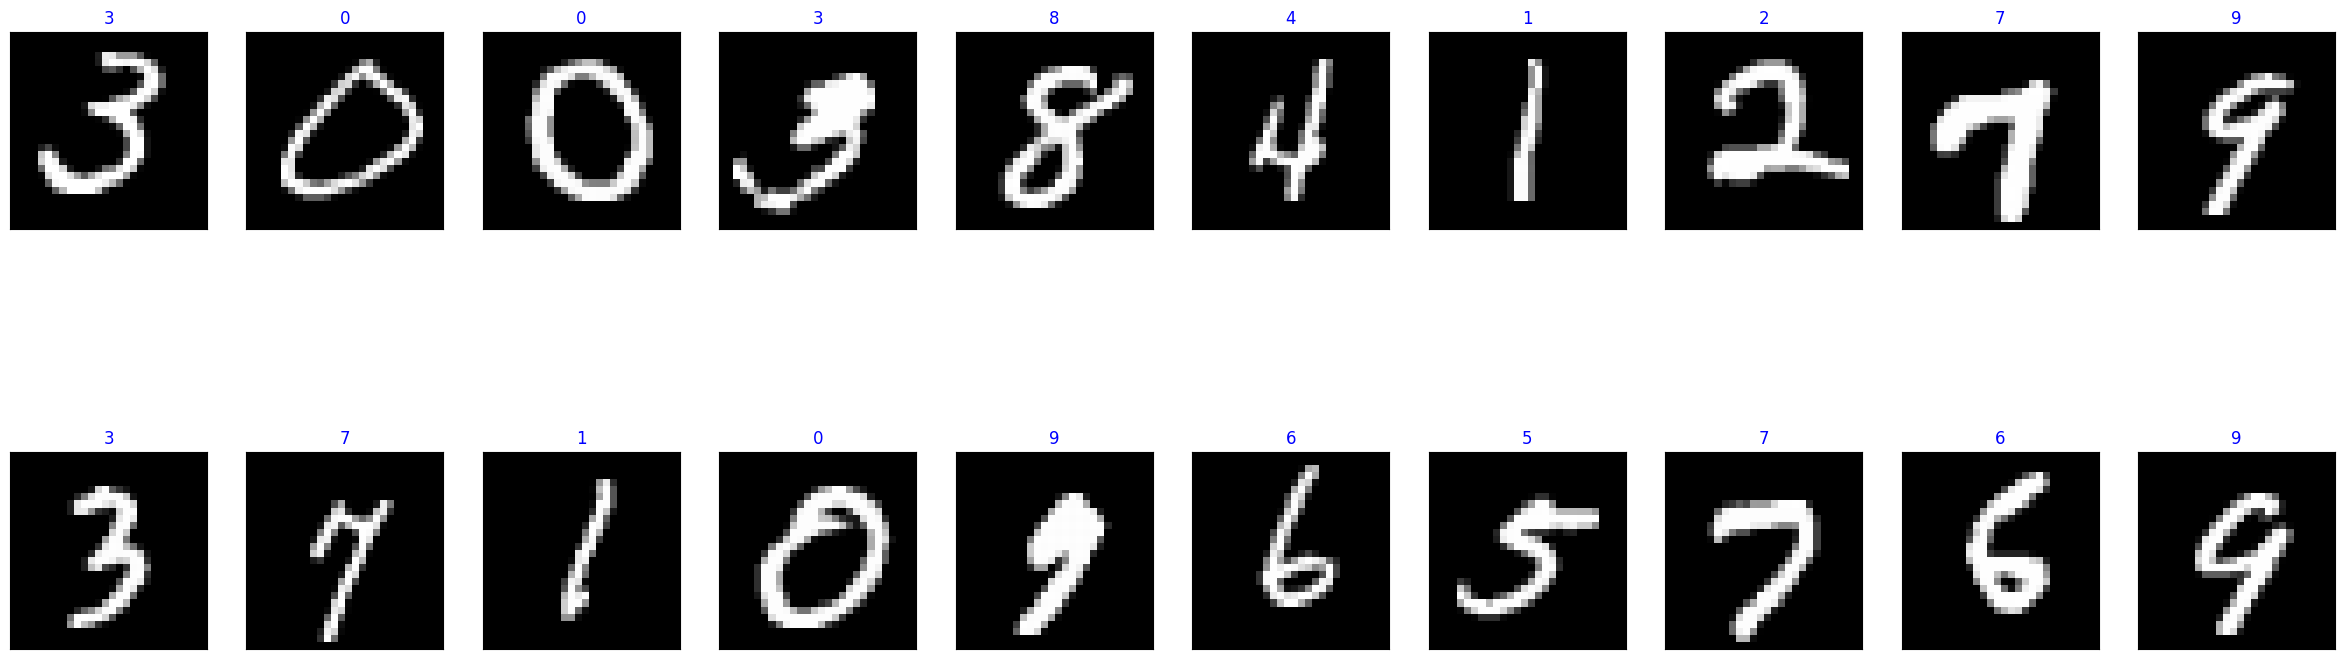

In [20]:
dataiter = iter(train_loader)
images, labels = next(dataiter)
print(images.shape, len(images), images[0].shape)
print(labels, labels.shape, len(labels))

fig = plt.figure(figsize=(30, 10))
for i in range(len(labels)):
    ax = fig.add_subplot(2, 10, i+1, xticks=[], yticks=[])
    plt.imshow(np.squeeze(images[i]), cmap='gray')
    ax.set_title(labels[i].item(), color='blue')
plt.show()

In [21]:
class F_Auto_MNIST(nn.Module):
    def __init__(self, en_dim):
        super(F_Auto_MNIST, self).__init__()
        self.encoder = nn.Linear(784, en_dim)
        self.decoder = nn.Linear(en_dim, 784)

    def forward(self, x):
        x = F.relu(self.encoder(x))
        x = torch.sigmoid(self.decoder(x))
        return x


class Tran_conv_Auto_MNIST(nn.Module):
    def __init__(self):
        super(Tran_conv_Auto_MNIST, self).__init__()
        self.en_conv1 = nn.Conv2d(1, 16, 3, padding=1)
        self.en_conv2 = nn.Conv2d(16, 4, 3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.de_conv1 = nn.ConvTranspose2d(4, 16, 2, stride=2)
        self.de_conv2 = nn.ConvTranspose2d(16, 1, 2, stride=2)

    def forward(self, x):
        x = self.pool(F.relu(self.en_conv1(x)))
        x = self.pool(F.relu(self.en_conv2(x)))
        x = F.relu(self.de_conv1(x))
        x = torch.sigmoid(self.de_conv2(x))
        return x


class upsamp_conv_Auto_MNIST(nn.Module):
    def __init__(self):
        super(upsamp_conv_Auto_MNIST, self).__init__()
        self.en_conv1 = nn.Conv2d(1, 16, 3, padding=1)
        self.en_conv2 = nn.Conv2d(16, 4, 3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.de_conv1 = nn.Conv2d(4, 16, 3, padding=1)
        self.de_conv2 = nn.Conv2d(16, 1, 3, padding=1)

    def forward(self, x):
        x = self.pool(F.relu(self.en_conv1(x)))
        x = self.pool(F.relu(self.en_conv2(x)))
        x = F.interpolate(x, scale_factor=2, mode='nearest')
        x = F.relu(self.de_conv1(x))
        x = F.interpolate(x, scale_factor=2, mode='nearest')
        x = torch.sigmoid(self.de_conv2(x))
        return x

In [22]:
model_1 = F_Auto_MNIST(32)
model_2 = Tran_conv_Auto_MNIST()
model_3 = upsamp_conv_Auto_MNIST()

def weight_init_normal(m):
    classname = m.__class__.__name__
    if classname.find('Linear') != -1:
        n = m.in_features
        y = 1.0 / np.sqrt(n)
        m.weight.data.normal_(0, y)
        m.bias.data.fill_(0)

model_1.apply(weight_init_normal)

use_cuda = True
if use_cuda and torch.cuda.is_available():
    model_1.cuda()
    model_2.cuda()
    model_3.cuda()

print(model_1, '\n\n\n\n', model_2, '\n\n\n\n', model_3, '\n\n\n\n', 'On GPU:', torch.cuda.is_available())

F_Auto_MNIST(
  (encoder): Linear(in_features=784, out_features=32, bias=True)
  (decoder): Linear(in_features=32, out_features=784, bias=True)
) 



 Tran_conv_Auto_MNIST(
  (en_conv1): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (en_conv2): Conv2d(16, 4, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (de_conv1): ConvTranspose2d(4, 16, kernel_size=(2, 2), stride=(2, 2))
  (de_conv2): ConvTranspose2d(16, 1, kernel_size=(2, 2), stride=(2, 2))
) 



 upsamp_conv_Auto_MNIST(
  (en_conv1): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (en_conv2): Conv2d(16, 4, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (de_conv1): Conv2d(4, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (de_conv2): Conv2d(16, 1, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
) 



 O

In [23]:
criterion = nn.MSELoss()

In [24]:
def add_noise(images, noise_factor=0.5):
    noisy = images + noise_factor * torch.randn_like(images)
    noisy = torch.clamp(noisy, 0., 1.)
    return noisy


def trainNet(model, lr, state='fully'):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    loss_keeper = {'train': [], 'valid': []}
    epochs = 20
    valid_loss_min = np.inf

    for epoch in range(epochs):
        train_loss = 0.0
        valid_loss = 0.0

        model.train()
        for images, _ in train_loader:
            if use_cuda and torch.cuda.is_available():
                images = images.cuda()
            noisy_images = add_noise(images)
            if state == 'fully':
                images = images.view(images.size(0), -1)
                noisy_images = noisy_images.view(noisy_images.size(0), -1)
            optimizer.zero_grad()
            output = model(noisy_images)
            loss = criterion(output, images)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()

        model.eval()
        with torch.no_grad():
            for images, _ in valid_loader:
                if use_cuda and torch.cuda.is_available():
                    images = images.cuda()
                noisy_images = add_noise(images)
                if state == 'fully':
                    images = images.view(images.size(0), -1)
                    noisy_images = noisy_images.view(noisy_images.size(0), -1)
                output = model(noisy_images)
                loss = criterion(output, images)
                valid_loss += loss.item()

        train_loss = train_loss / len(train_loader)
        valid_loss = valid_loss / len(valid_loader)

        loss_keeper['train'].append(train_loss)
        loss_keeper['valid'].append(valid_loss)

        print(f"\nEpoch: {epoch+1}\tTraining Loss: {train_loss:.6f}\tValidation Loss: {valid_loss:.6f}")
        if valid_loss <= valid_loss_min:
            print(f"Validation loss decreased from: {valid_loss_min:.6f} ----> {valid_loss:.6f} ----> Saving Model...")
            z = type(model).__name__
            torch.save(model.state_dict(), z + '_model.pth')
            valid_loss_min = valid_loss

    return loss_keeper

In [25]:
m1_loss = trainNet(model_1, 0.01)


Epoch: 1	Training Loss: 0.042166	Validation Loss: 0.039667
Validation loss decreased from: inf ----> 0.039667 ----> Saving Model...

Epoch: 2	Training Loss: 0.038979	Validation Loss: 0.038237
Validation loss decreased from: 0.039667 ----> 0.038237 ----> Saving Model...

Epoch: 3	Training Loss: 0.038528	Validation Loss: 0.038924

Epoch: 4	Training Loss: 0.038377	Validation Loss: 0.038173
Validation loss decreased from: 0.038237 ----> 0.038173 ----> Saving Model...

Epoch: 5	Training Loss: 0.038205	Validation Loss: 0.039163

Epoch: 6	Training Loss: 0.038135	Validation Loss: 0.038338

Epoch: 7	Training Loss: 0.038105	Validation Loss: 0.039049

Epoch: 8	Training Loss: 0.038132	Validation Loss: 0.038201

Epoch: 9	Training Loss: 0.038060	Validation Loss: 0.038016
Validation loss decreased from: 0.038173 ----> 0.038016 ----> Saving Model...

Epoch: 10	Training Loss: 0.038032	Validation Loss: 0.037626
Validation loss decreased from: 0.038016 ----> 0.037626 ----> Saving Model...

Epoch: 11	Tra

In [26]:
m2_loss = trainNet(model_2, 0.01, 'conv')


Epoch: 1	Training Loss: 0.038346	Validation Loss: 0.033346
Validation loss decreased from: inf ----> 0.033346 ----> Saving Model...

Epoch: 2	Training Loss: 0.033247	Validation Loss: 0.032441
Validation loss decreased from: 0.033346 ----> 0.032441 ----> Saving Model...

Epoch: 3	Training Loss: 0.032816	Validation Loss: 0.032343
Validation loss decreased from: 0.032441 ----> 0.032343 ----> Saving Model...

Epoch: 4	Training Loss: 0.032705	Validation Loss: 0.032964

Epoch: 5	Training Loss: 0.032596	Validation Loss: 0.032324
Validation loss decreased from: 0.032343 ----> 0.032324 ----> Saving Model...

Epoch: 6	Training Loss: 0.032268	Validation Loss: 0.031967
Validation loss decreased from: 0.032324 ----> 0.031967 ----> Saving Model...

Epoch: 7	Training Loss: 0.032078	Validation Loss: 0.031651
Validation loss decreased from: 0.031967 ----> 0.031651 ----> Saving Model...

Epoch: 8	Training Loss: 0.031978	Validation Loss: 0.031638
Validation loss decreased from: 0.031651 ----> 0.031638 -

In [27]:
m3_loss = trainNet(model_3, 0.01, 'conv')


Epoch: 1	Training Loss: 0.112342	Validation Loss: 0.111327
Validation loss decreased from: inf ----> 0.111327 ----> Saving Model...

Epoch: 2	Training Loss: 0.112172	Validation Loss: 0.111327

Epoch: 3	Training Loss: 0.112172	Validation Loss: 0.111327
Validation loss decreased from: 0.111327 ----> 0.111327 ----> Saving Model...

Epoch: 4	Training Loss: 0.112172	Validation Loss: 0.111327

Epoch: 5	Training Loss: 0.112172	Validation Loss: 0.111327

Epoch: 6	Training Loss: 0.112172	Validation Loss: 0.111327

Epoch: 7	Training Loss: 0.112172	Validation Loss: 0.111327

Epoch: 8	Training Loss: 0.112172	Validation Loss: 0.111327
Validation loss decreased from: 0.111327 ----> 0.111327 ----> Saving Model...

Epoch: 9	Training Loss: 0.112172	Validation Loss: 0.111327

Epoch: 10	Training Loss: 0.112172	Validation Loss: 0.111327

Epoch: 11	Training Loss: 0.112172	Validation Loss: 0.111327

Epoch: 12	Training Loss: 0.112172	Validation Loss: 0.111327

Epoch: 13	Training Loss: 0.112172	Validation Lo

In [28]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model_1.load_state_dict(torch.load('F_Auto_MNIST_model.pth', map_location=device))
model_2.load_state_dict(torch.load('Tran_conv_Auto_MNIST_model.pth', map_location=device))
model_3.load_state_dict(torch.load('upsamp_conv_Auto_MNIST_model.pth', map_location=device))

<All keys matched successfully>

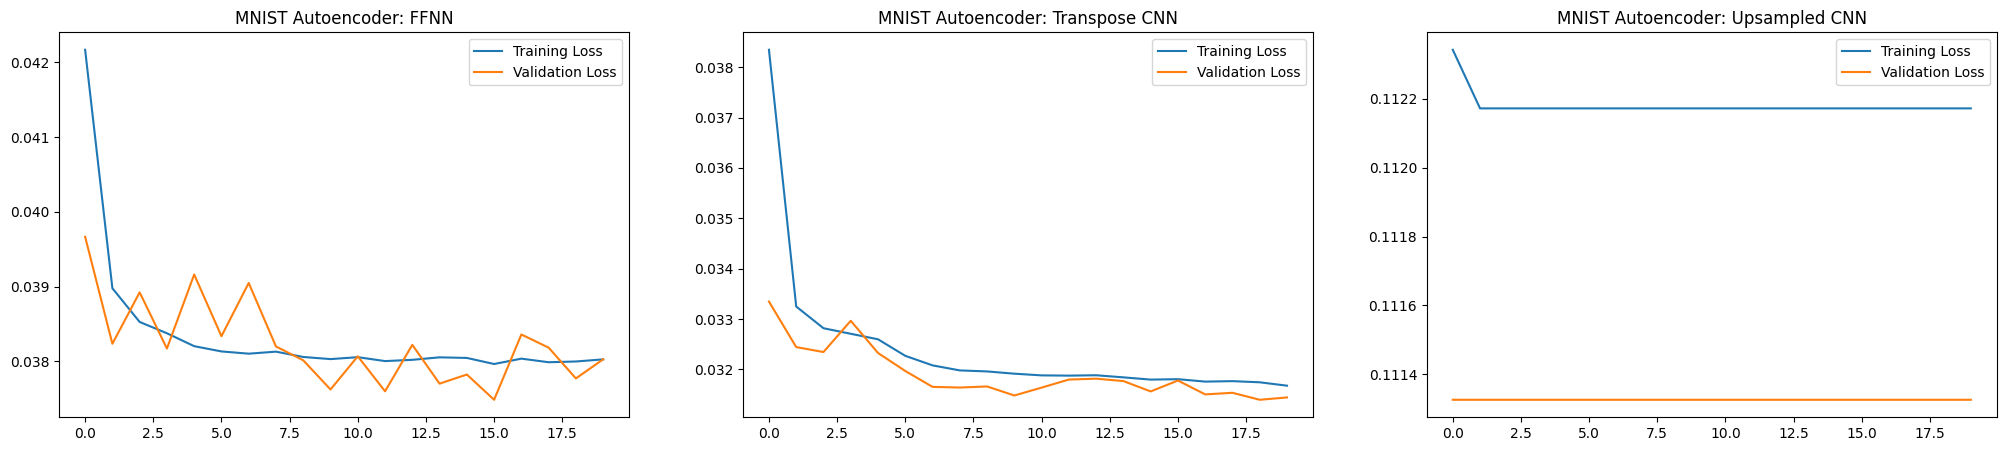

In [29]:
title = ['FFNN', 'Transpose CNN', 'Upsampled CNN']
model_losses = [m1_loss, m2_loss, m3_loss]

fig = plt.figure(1, figsize=(25, 5))
idx = 1
for i in model_losses:
    ax = fig.add_subplot(1, 3, idx)
    ax.plot(i['train'], label='Training Loss')
    ax.plot(i['valid'], label='Validation Loss')
    ax.set_title('MNIST Autoencoder: ' + title[idx-1])
    idx += 1
    plt.legend()
plt.show()

In [30]:
def test(model, state='fully'):
    dataiter = iter(test_loader)
    images, _ = next(dataiter)
    if use_cuda and torch.cuda.is_available():
        images = images.cuda()
    noisy_images = add_noise(images)
    model.eval()
    with torch.no_grad():
        if state == 'fully':
            noisy_flat = noisy_images.view(noisy_images.size(0), -1)
            output = model(noisy_flat)
            output = output.view(batch_size, 1, 28, 28)
        else:
            output = model(noisy_images)
            output = output.view(batch_size, 1, 28, 28)

    noisy_display = noisy_images.cpu().numpy()
    images_display = images.cpu().numpy()
    output_display = output.cpu().numpy()

    fig, axes = plt.subplots(nrows=3, ncols=10, sharex=True, sharey=True, figsize=(25, 6))

    for img, ax in zip(noisy_display[:10], axes[0]):
        ax.imshow(np.squeeze(img), cmap='gray')
        ax.get_xaxis().set_visible(False)
        ax.get_yaxis().set_visible(False)
    axes[0][0].set_ylabel('Noisy', fontsize=12)

    for img, ax in zip(images_display[:10], axes[1]):
        ax.imshow(np.squeeze(img), cmap='gray')
        ax.get_xaxis().set_visible(False)
        ax.get_yaxis().set_visible(False)
    axes[1][0].set_ylabel('Original', fontsize=12)

    for img, ax in zip(output_display[:10], axes[2]):
        ax.imshow(np.squeeze(img), cmap='gray')
        ax.get_xaxis().set_visible(False)
        ax.get_yaxis().set_visible(False)
    axes[2][0].set_ylabel('Denoised', fontsize=12)

    plt.suptitle(f'MNIST Denoising - {type(model).__name__}', fontsize=14)
    plt.show()

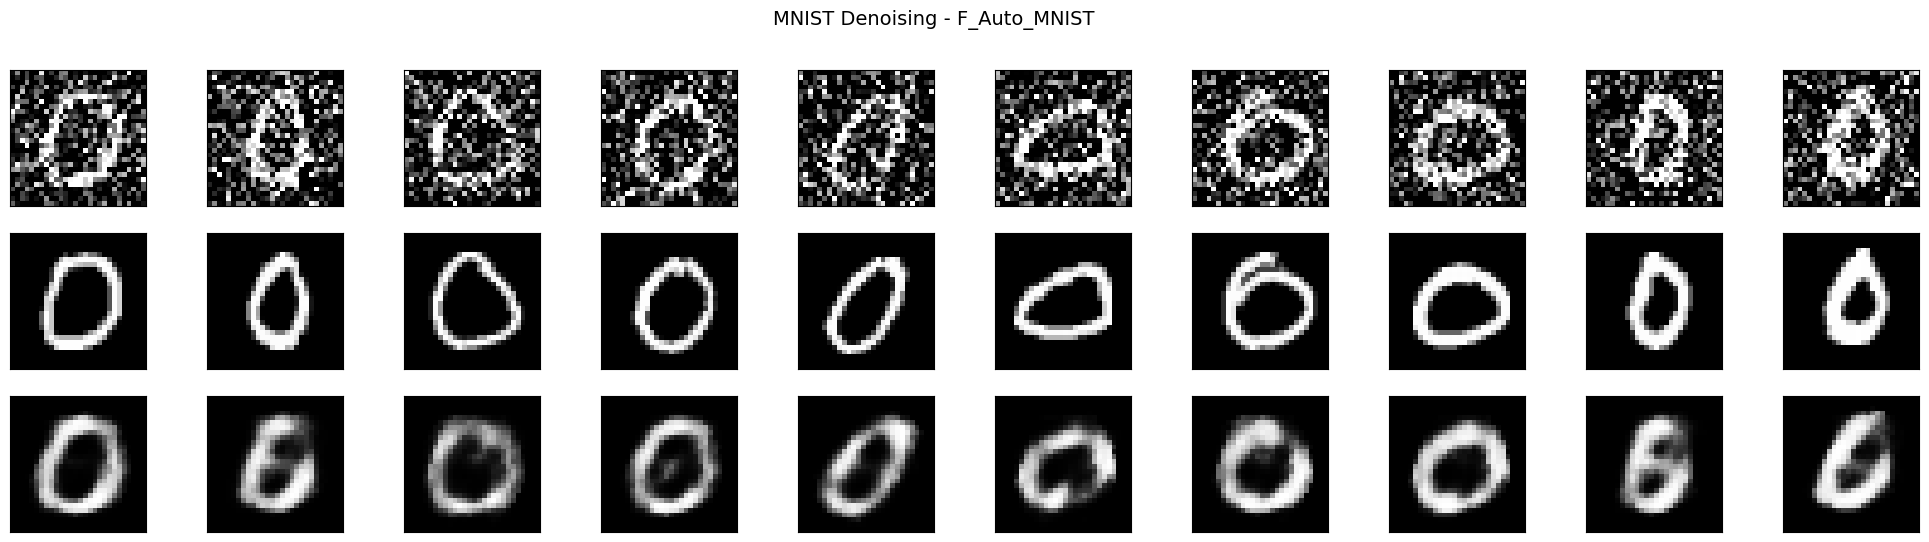

In [31]:
test(model_1)

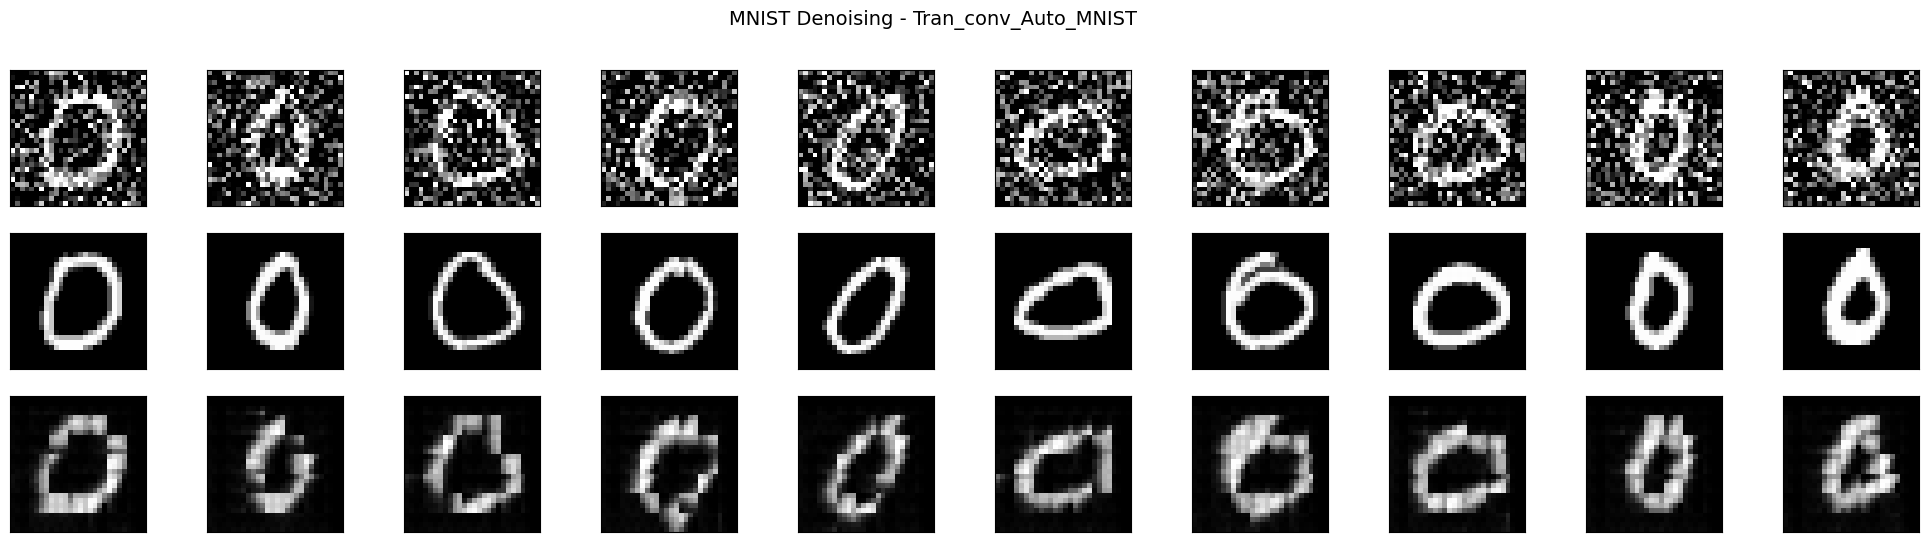

In [32]:
test(model_2, 'conv')

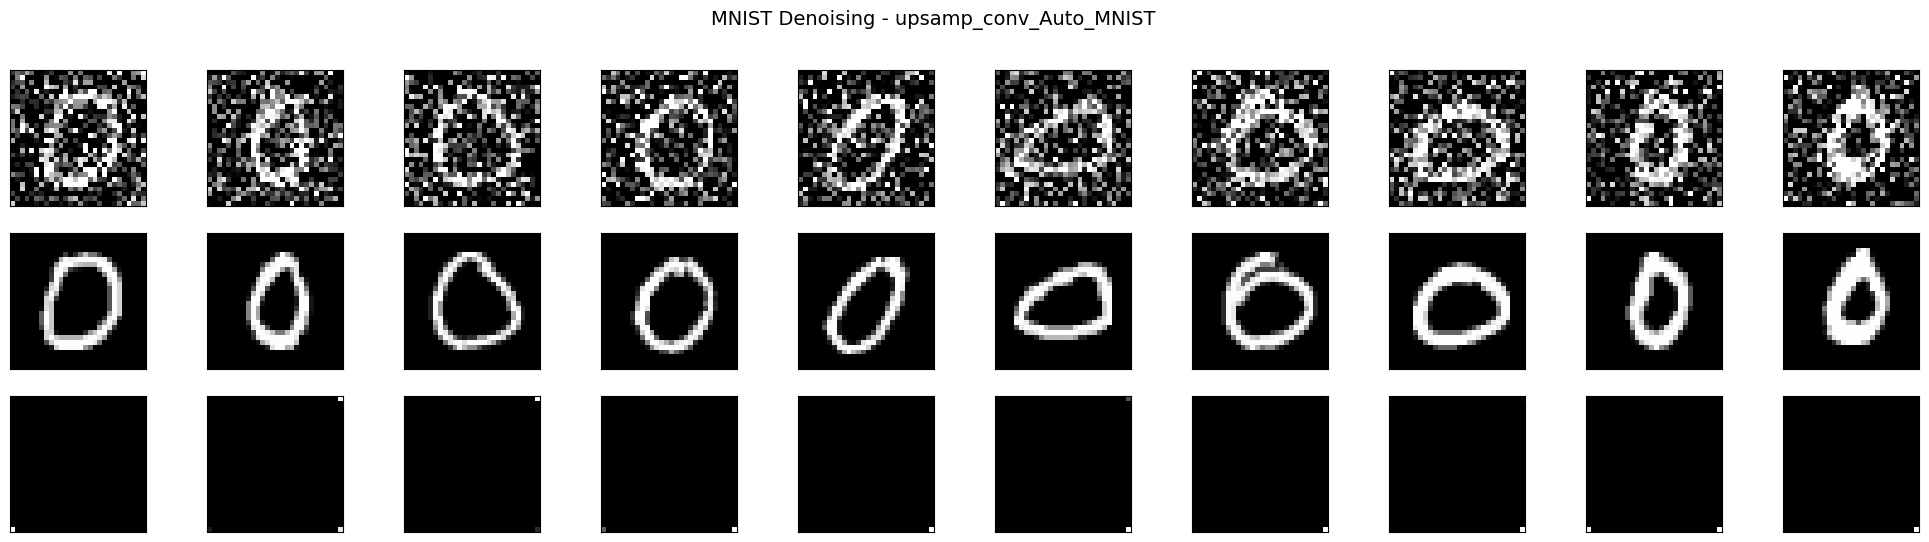

In [33]:
test(model_3, 'conv')